# Hardest Route to the Title — Elo vs FIFA

We score every Round-of-32 team's **road to the trophy** through the real
[official 2026 knockout bracket](https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_knockout_stage)
(hard-coded in `knockout_paths_elo.bracket`). Who you face each round is the
winner of the sibling sub-bracket, so expected opponents are weighted by how
likely each rival is to actually be there.

We run the analysis **separately under two independent rating systems**:

1. **Eloratings** — World Football Elo (`data/elo_ratings.csv`, `rating`), win
   probability on the classic **/400** scale.
2. **FIFA** — the FIFA/Coca-Cola ranking (`data/fifa_rankings.csv`). Two angles:
   - **points** (`total_points`) with FIFA's own **/600** win-probability scale;
   - **ranking** (`rank`) — the average rank-number of opponents faced.

Higher expected opponent strength = **harder route**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_rows", 50)

# Make the project package importable when running from notebooks/.
for base in (Path.cwd(), *Path.cwd().parents):
    if (base / "knockout_paths_elo").is_dir():
        sys.path.insert(0, str(base))
        break

from knockout_paths_elo.bracket import (
    build_official_bracket,
    advancement_distribution,
    champion_probabilities,
    path_difficulty,
    win_probability,
    fifa_win_probability,
    R32_MATCHUPS,
)
print(sys.executable)

e:\Code\knockout-paths-elo\.venv\Scripts\python.exe


## 1. Load both rating systems

Both CSVs key teams by the same names used in the bracket, so lookups line up.

In [2]:
def data_dir() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "data" / "elo_ratings.csv").exists():
            return base / "data"
    raise FileNotFoundError("data/ not found")

DATA = data_dir()
elo_df = pd.read_csv(DATA / "elo_ratings.csv")
fifa_df = pd.read_csv(DATA / "fifa_rankings.csv")

elo_rating = dict(zip(elo_df["team"], elo_df["rating"]))
fifa_points = dict(zip(fifa_df["team"], fifa_df["total_points"]))
fifa_rank = dict(zip(fifa_df["team"], fifa_df["rank"]))

print(f"Elo: {len(elo_rating)} teams | FIFA: {len(fifa_points)} teams")

Elo: 48 teams | FIFA: 48 teams


## 2. The official bracket

`build_official_bracket()` turns the hard-coded R32 matchups into a 32-leaf
binary tree; advancement above the bottom layer is decided by the chosen rating
system.

In [3]:
root = build_official_bracket()
teams = [leaf.team for leaf in root.leaves()]
assert len(teams) == 32 and set(teams) <= set(elo_rating) and set(teams) <= set(fifa_points)

print(f"Tree: {root.size} leaves, root round = {root.round_name}\n")
print("Round of 32 matchups (bracket order):")
for a, b in R32_MATCHUPS:
    print(f"  {a:<22} vs  {b}")

Tree: 32 leaves, root round = Final

Round of 32 matchups (bracket order):
  Germany                vs  Paraguay
  France                 vs  Sweden
  South Africa           vs  Canada
  Netherlands            vs  Morocco
  Portugal               vs  Croatia
  Spain                  vs  Austria
  USA                    vs  Bosnia & Herzegovina
  Belgium                vs  Senegal
  Brazil                 vs  Japan
  Ivory Coast            vs  Norway
  Mexico                 vs  Ecuador
  England                vs  DR Congo
  Argentina              vs  Cape Verde
  Australia              vs  Egypt
  Switzerland            vs  Algeria
  Colombia               vs  Ghana


## 3. Scoring helpers

`path_difficulty` (from the module) gives, per team, the expected opponent
**rating** each round and the product of round win-probabilities (= probability
of running the table = winning the title). `avg_opp_rating` is the per-round mean
— our headline "hardness" number. For the FIFA-ranking view we also average the
opponents' **rank-number** using the same advancement distributions.

In [4]:
def difficulty_table(root, teams, ratings, prob, rating_label):
    rows = []
    for t in teams:
        pdif = path_difficulty(root, t, ratings, prob)
        rows.append({
            "team": t,
            rating_label: ratings[t],
            "avg_opp_" + rating_label: pdif.strength_of_schedule / len(pdif.steps),
            "p_champion": pdif.run_the_table_prob,
        })
    df = pd.DataFrame(rows)
    df["hardness_rank"] = df["avg_opp_" + rating_label].rank(ascending=False).astype(int)
    return df.sort_values("avg_opp_" + rating_label, ascending=False).reset_index(drop=True)


def opponents_per_round(root, team, ratings, prob):
    # -> [(round_name, {opponent: P(faces them)})] from R32 to Final
    path = []
    def find(n):
        path.append(n)
        if n.is_leaf:
            if n.team == team:
                return True
        elif find(n.left) or find(n.right):
            return True
        path.pop()
        return False
    find(root)
    out = []
    for parent, child in zip(path, path[1:]):
        sib = parent.right if parent.left is child else parent.left
        out.append((parent.round_name, advancement_distribution(sib, ratings, prob)))
    return list(reversed(out))


def show_road(root, team, ratings, prob, unit):
    pdif = path_difficulty(root, team, ratings, prob)
    print(f"Round-by-round road for {team}:")
    for s in pdif.steps:
        print(f"  {s.round_name:<6} exp opp {unit} {s.exp_opponent_rating:7.0f}"
              f"   win prob {s.exp_win_prob:5.1%}")


def plot_hardest(df, value_col, title, xlabel, color, ascending_hard=False, n=32):
    top = df.sort_values(value_col, ascending=ascending_hard).head(n)[::-1]
    fig, ax = plt.subplots(figsize=(9, max(6, 0.32 * len(top))))
    ax.barh(top["team"], top[value_col], color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

## 4. Hardest route — Eloratings  (/400)

In [119]:
elo_routes = difficulty_table(root, teams, elo_rating, win_probability, "elo")
elo_routes

,team,elo,avg_opp_elo,p_champion,hardness_rank
0,DR Congo,1666,2004.334109,0.000040,1
1,Algeria,1780,2002.963730,0.000620,2
2,Austria,1841,2002.528416,0.001688,3
3,Ghana,1584,2001.323955,0.000007,4
4,Ivory Coast,1743,2001.076160,0.000271,5
5,Croatia,1896,2000.331647,0.005337,6
6,Japan,1910,1998.866907,0.007173,7
7,Sweden,1742,1997.752131,0.000268,8
8,Paraguay,1815,1997.348491,0.001398,9
9,Ecuador,1902,1997.292285,0.006636,10


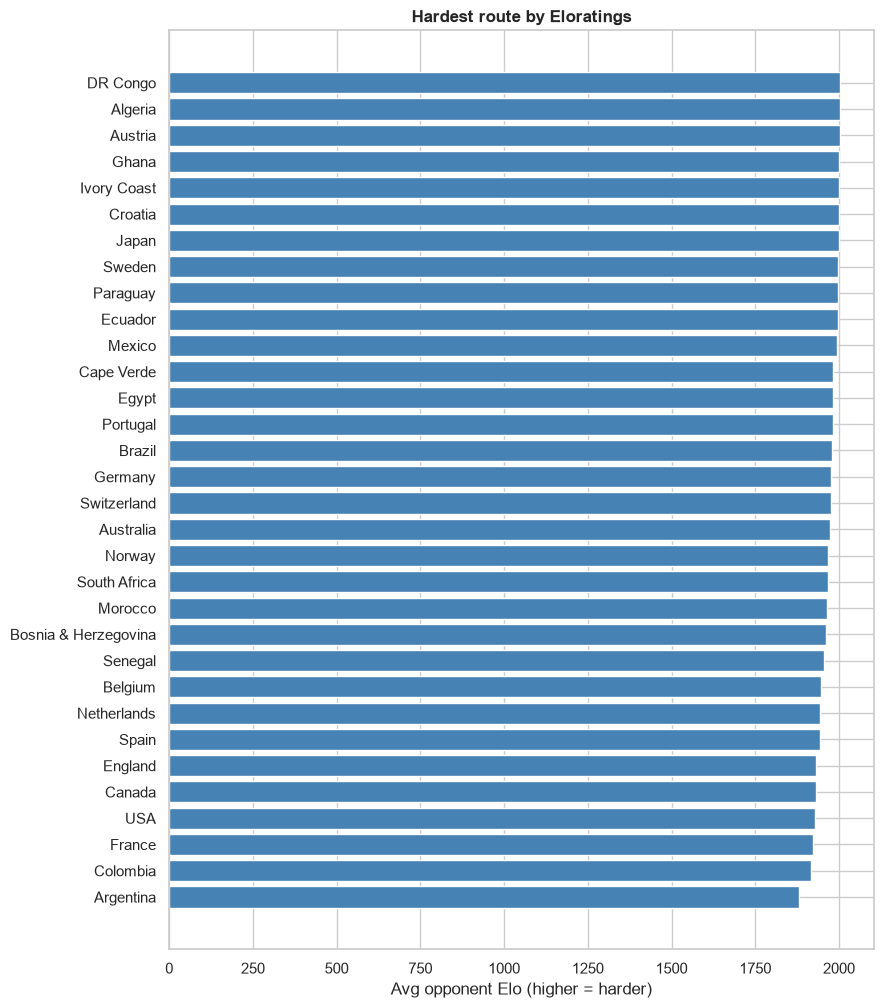

Round-by-round road for DR Congo:
  Final  exp opp Elo    2028   win prob 11.1%
  SF     exp opp Elo    1907   win prob 20.0%
  QF     exp opp Elo    1946   win prob 17.3%
  R16    exp opp Elo    2072   win prob 10.2%
  R32    exp opp Elo    2068   win prob 10.3%


In [120]:
plot_hardest(elo_routes, "avg_opp_elo",
             "Hardest route by Eloratings", "Avg opponent Elo (higher = harder)",
             "steelblue")
show_road(root, elo_routes.iloc[0]["team"], elo_rating, win_probability, "Elo")

## 5. Hardest route — FIFA points  (/600)

In [121]:
fifa_routes = difficulty_table(root, teams, fifa_points, fifa_win_probability, "fifapts")
fifa_routes

,team,fifapts,avg_opp_fifapts,p_champion,hardness_rank
0,Austria,1597,1765.207639,0.004810,1
1,Croatia,1715,1755.736902,0.020605,2
2,Sweden,1510,1749.716505,0.001947,3
3,Paraguay,1505,1748.748753,0.001965,4
4,Portugal,1768,1745.136902,0.037654,5
5,Bosnia & Herzegovina,1387,1740.525023,0.000401,6
6,DR Congo,1474,1734.247601,0.001487,7
7,Senegal,1684,1731.389092,0.018693,8
8,Ecuador,1599,1727.098438,0.008152,9
9,South Africa,1428,1722.037533,0.000931,10


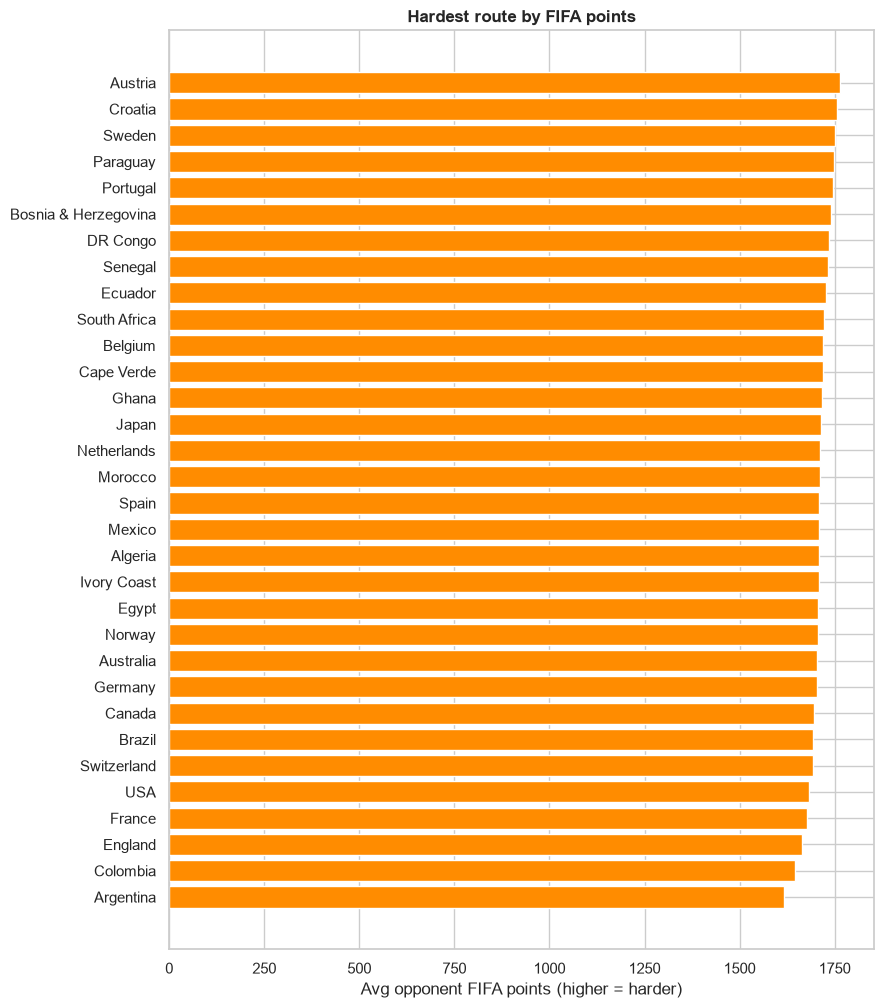

Round-by-round road for Austria:
  Final  exp opp pts    1875   win prob 25.6%
  SF     exp opp pts    1744   win prob 36.3%
  QF     exp opp pts    1683   win prob 41.8%
  R16    exp opp pts    1763   win prob 35.1%
  R32    exp opp pts    1761   win prob 35.3%


In [122]:
plot_hardest(fifa_routes, "avg_opp_fifapts",
             "Hardest route by FIFA points", "Avg opponent FIFA points (higher = harder)",
             "darkorange")
show_road(root, fifa_routes.iloc[0]["team"], fifa_points, fifa_win_probability, "pts")

## 6. Hardest route — FIFA ranking

Average **rank-number** of expected opponents (lower number = stronger field =
harder). Who advances is decided by the FIFA points model.

In [123]:
rank_rows = []
for t in teams:
    steps = opponents_per_round(root, t, fifa_points, fifa_win_probability)
    exp_ranks = [sum(p * fifa_rank[o] for o, p in dist.items()) for _, dist in steps]
    rank_rows.append({
        "team": t,
        "fifa_rank": fifa_rank[t],
        "avg_opp_fifa_rank": float(np.mean(exp_ranks)),
    })
rank_routes = pd.DataFrame(rank_rows)
rank_routes["hardness_rank"] = rank_routes["avg_opp_fifa_rank"].rank(ascending=True).astype(int)
rank_routes = rank_routes.sort_values("avg_opp_fifa_rank").reset_index(drop=True)
rank_routes

,team,fifa_rank,avg_opp_fifa_rank,hardness_rank
0,Austria,24,9.222701,1
1,Croatia,11,9.809909,2
2,Portugal,5,11.009909,3
3,Bosnia & Herzegovina,64,11.052183,4
4,Paraguay,41,11.094548,5
5,Sweden,38,11.502902,6
6,DR Congo,46,11.919165,7
7,Senegal,15,12.884090,8
8,Ecuador,23,12.887341,9
9,South Africa,60,13.419951,10


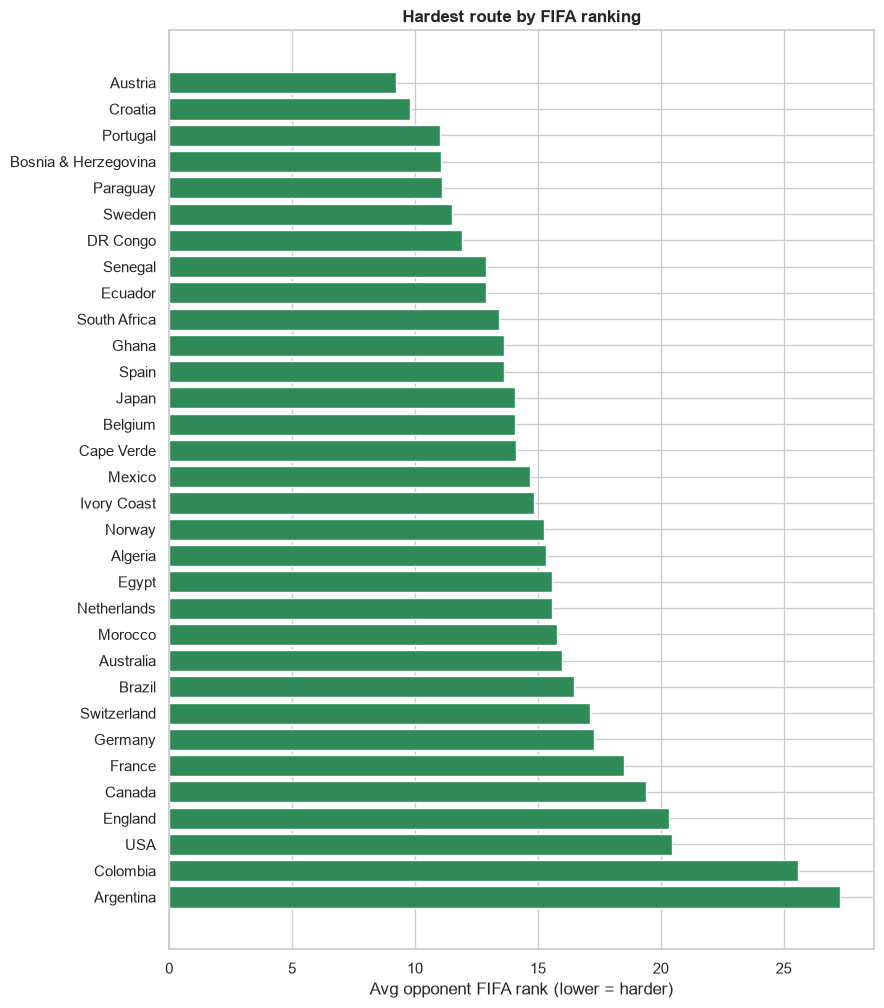

In [124]:
plot_hardest(rank_routes, "avg_opp_fifa_rank",
             "Hardest route by FIFA ranking", "Avg opponent FIFA rank (lower = harder)",
             "seagreen", ascending_hard=True)

## 7. Side-by-side

Each system's hardness rank (1 = toughest road). Elo and FIFA-points reward
beating high-rated teams; FIFA-ranking rewards facing low rank-numbers — they
mostly agree but can disagree where the two systems disagree on a team's strength.

In [125]:
compare = (
    elo_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "elo_rank"})
    .merge(fifa_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "fifapts_rank"}), on="team")
    .merge(rank_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "fifarank_rank"}), on="team")
)
compare["avg_rank"] = compare[["elo_rank", "fifapts_rank", "fifarank_rank"]].mean(axis=1)
compare.sort_values("avg_rank").reset_index(drop=True)

,team,elo_rank,fifapts_rank,fifarank_rank,avg_rank
0,Austria,3,1,1,1.666667
1,Croatia,6,2,2,3.333333
2,DR Congo,1,7,7,5.000000
3,Sweden,8,3,6,5.666667
4,Paraguay,9,4,5,6.000000
5,Portugal,14,5,3,7.333333
6,Ghana,4,13,11,9.333333
7,Ecuador,10,9,9,9.333333
8,Bosnia & Herzegovina,22,6,4,10.666667
9,Japan,7,14,13,11.333333


## 8. Bonus — most probable winner under each system

The product of expected round win-probs along a team's path is exactly its title
probability, so each system also yields a favourite.

In [126]:
champ_elo = champion_probabilities(root, elo_rating, win_probability)
champ_fifa = champion_probabilities(root, fifa_points, fifa_win_probability)

winners = (
    pd.DataFrame({"team": teams})
    .assign(p_elo=lambda d: d["team"].map(champ_elo),
            p_fifa=lambda d: d["team"].map(champ_fifa))
    .sort_values("p_elo", ascending=False)
    .reset_index(drop=True)
)
winners.style.format({"p_elo": "{:.1%}", "p_fifa": "{:.1%}"})

,team,p_elo,p_fifa
0,Argentina,26.9%,17.8%
1,Spain,21.5%,11.3%
2,France,19.8%,12.9%
3,England,7.0%,10.6%
4,Colombia,5.4%,4.0%
5,Brazil,4.1%,5.5%
6,Netherlands,3.7%,4.2%
7,Portugal,2.8%,3.8%
8,Norway,1.2%,0.6%
9,Germany,1.1%,3.8%


## 9. Easiest routes (inverse)

The mirror image of the hardest-route charts above: same metric for each system,
but now the team with the **softest** expected road sits on top.

In [127]:
def plot_easiest(df, value_col, title, xlabel, color, ascending_hard=False, n=32):
    # Easiest = the opposite extreme of the hardness metric used in plot_hardest.
    top = df.sort_values(value_col, ascending=not ascending_hard).head(n)[::-1]
    fig, ax = plt.subplots(figsize=(9, max(6, 0.32 * len(top))))
    ax.barh(top["team"], top[value_col], color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

### Easiest route — Eloratings

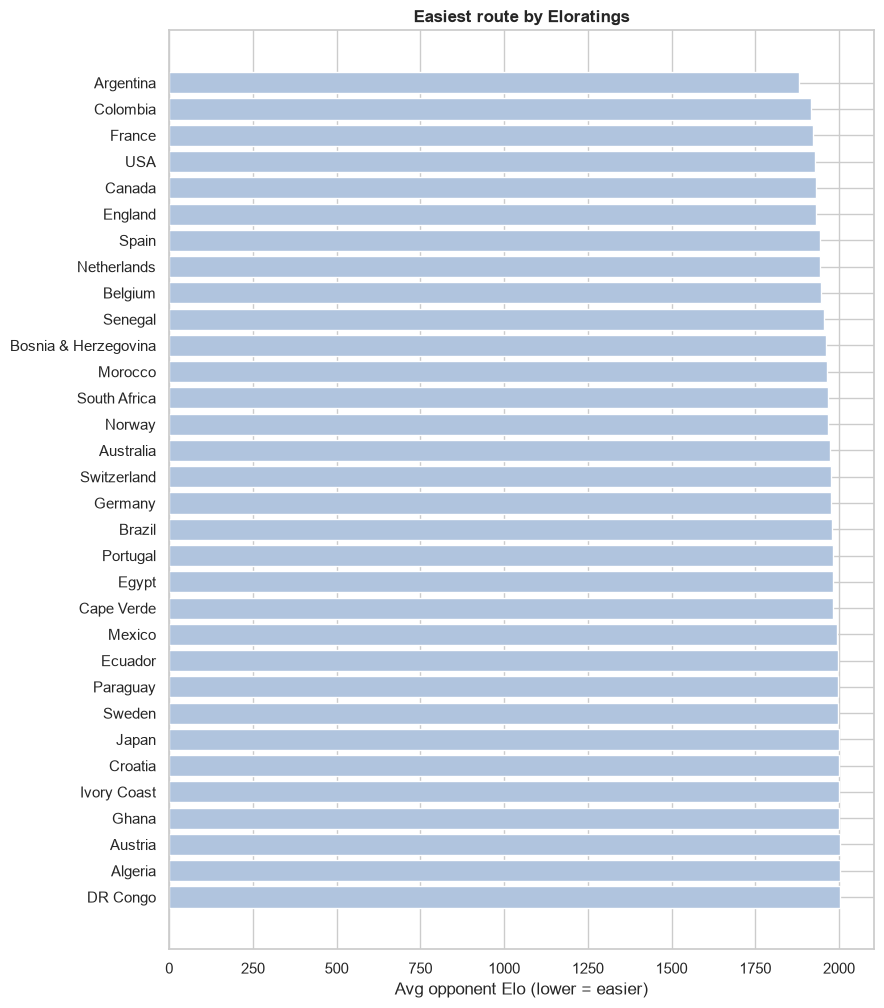

In [128]:
plot_easiest(elo_routes, "avg_opp_elo",
             "Easiest route by Eloratings", "Avg opponent Elo (lower = easier)",
             "lightsteelblue")

### Easiest route — FIFA points

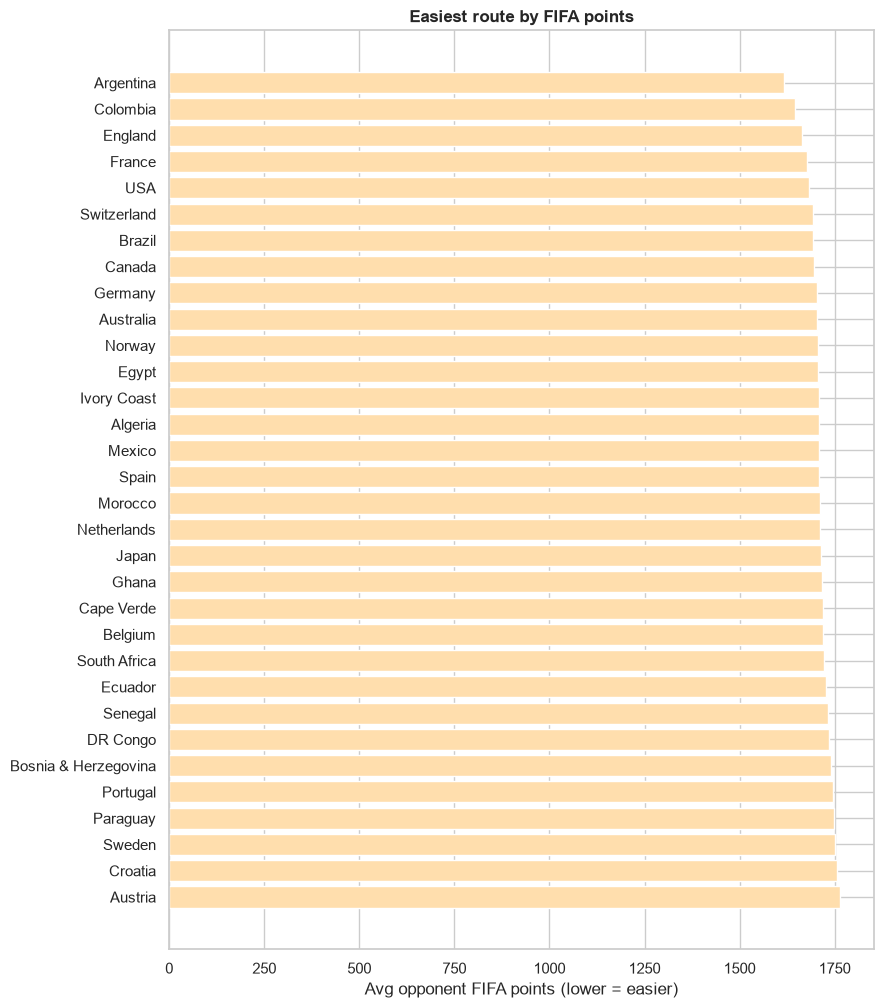

In [129]:
plot_easiest(fifa_routes, "avg_opp_fifapts",
             "Easiest route by FIFA points", "Avg opponent FIFA points (lower = easier)",
             "navajowhite")

### Easiest route — FIFA ranking

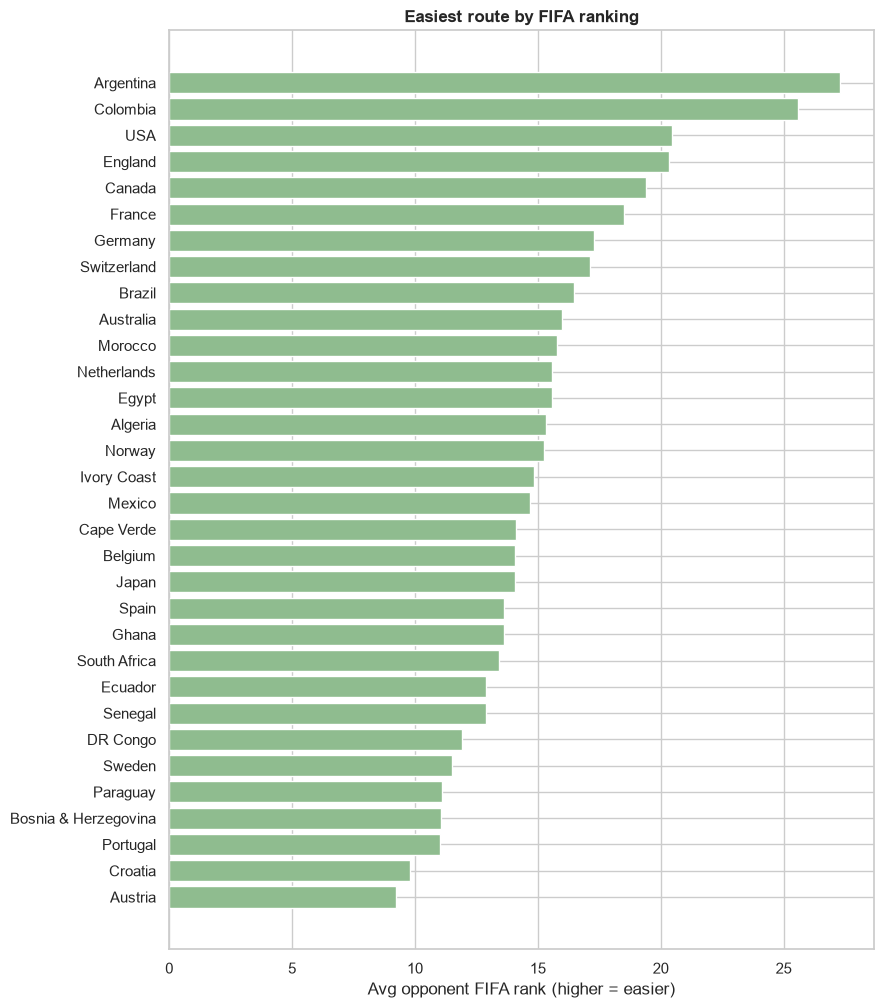

In [130]:
plot_easiest(rank_routes, "avg_opp_fifa_rank",
             "Easiest route by FIFA ranking", "Avg opponent FIFA rank (higher = easier)",
             "darkseagreen", ascending_hard=True)

## 10. Routes by Elo momentum (1-year change)

A **form** bracket: instead of absolute strength we use each team's Elo change
over the last year (`rating_change_1y`) as the rating. Advancement is decided by
who is trending up more, and a route is hard when the opponents you expect to
meet are the ones rising fastest. Values are deltas (can be negative) on the same
Elo scale, so we keep the /400 win-probability model.

In [131]:
form_rating = dict(zip(elo_df["team"], elo_df["rating_change_1y"]))
form_routes = difficulty_table(root, teams, form_rating, win_probability, "elo1y")
form_routes

,team,elo1y,avg_opp_elo1y,p_champion,hardness_rank
0,Norway,52,74.489833,0.021499,1
1,Colombia,56,74.271201,0.023635,2
2,Ecuador,-3,74.246850,0.009134,3
3,Argentina,12,72.735506,0.012043,4
4,Brazil,8,71.033560,0.011589,5
5,Switzerland,70,70.504138,0.030811,6
6,England,44,70.334231,0.021050,7
7,Australia,25,70.272959,0.015634,8
8,Algeria,76,69.304138,0.034120,9
9,Ghana,107,64.071201,0.055232,10


### Hardest route — Elo 1-year change

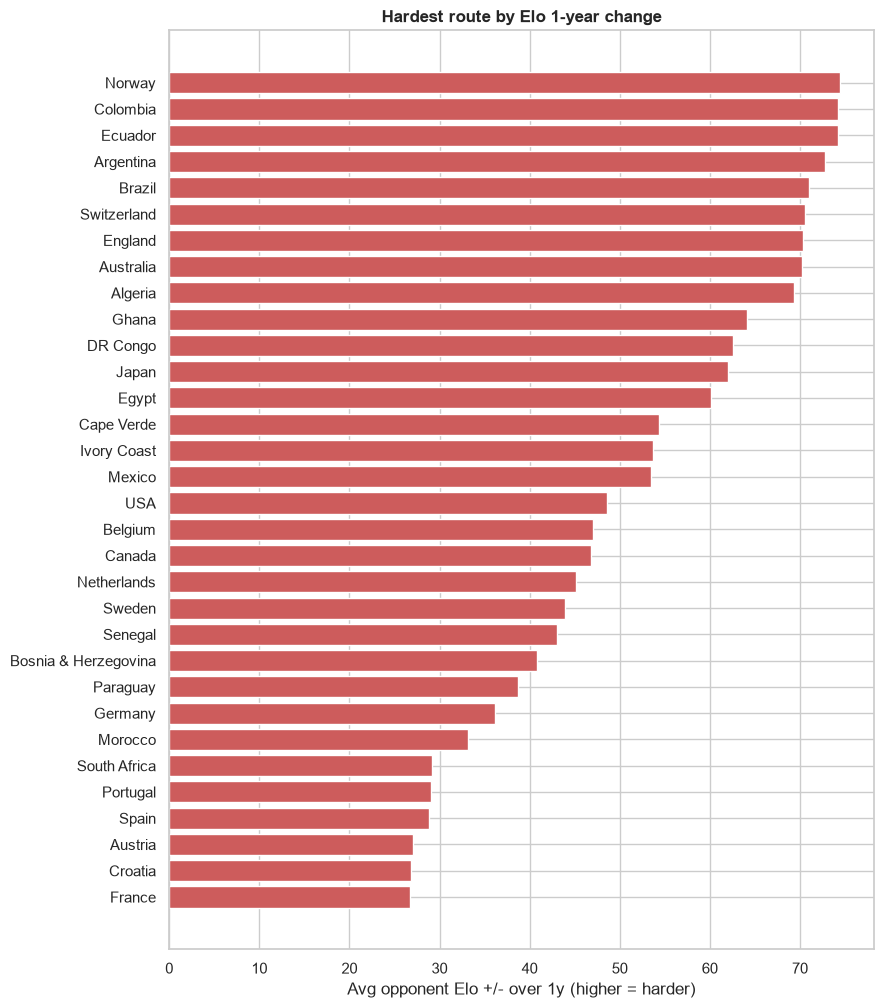

Round-by-round road for Norway:
  Final  exp opp dElo1y     156   win prob 35.5%
  SF     exp opp dElo1y      33   win prob 52.7%
  QF     exp opp dElo1y      69   win prob 47.6%
  R16    exp opp dElo1y      76   win prob 46.6%
  R32    exp opp dElo1y      38   win prob 51.9%


In [132]:
plot_hardest(form_routes, "avg_opp_elo1y",
             "Hardest route by Elo 1-year change",
             "Avg opponent Elo +/- over 1y (higher = harder)", "indianred")
show_road(root, form_routes.iloc[0]["team"], form_rating, win_probability, "dElo1y")

### Easiest route — Elo 1-year change

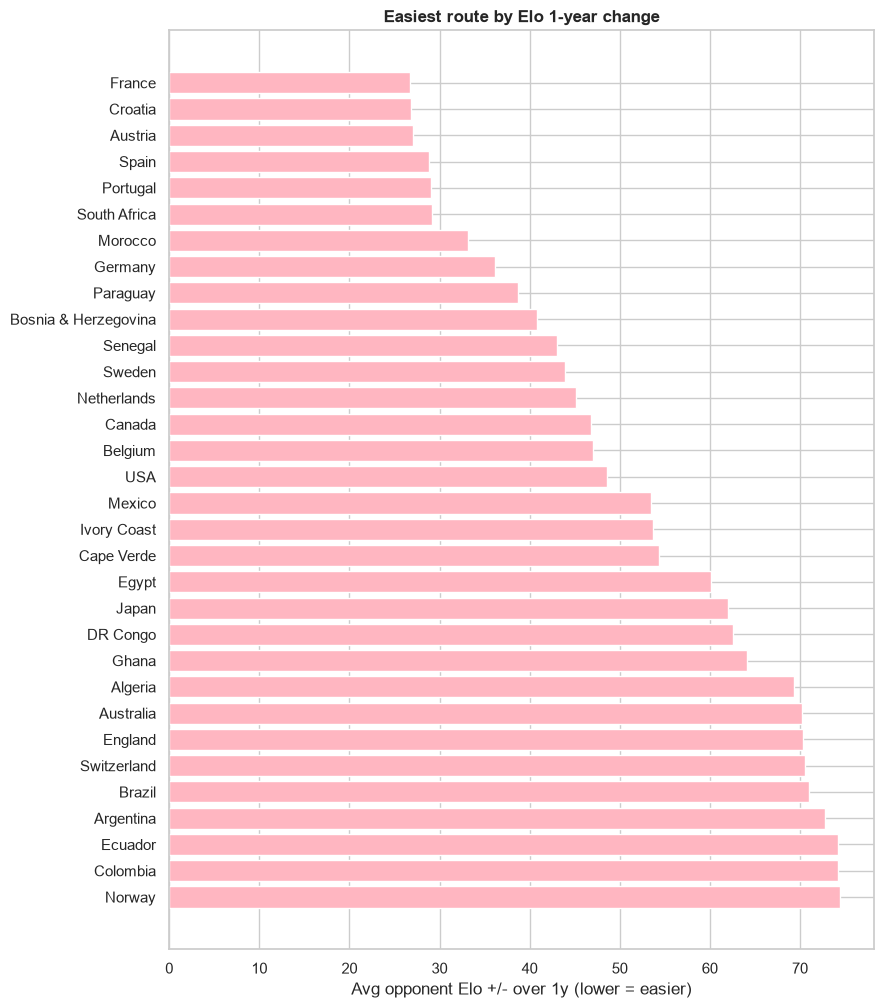

In [133]:
plot_easiest(form_routes, "avg_opp_elo1y",
             "Easiest route by Elo 1-year change",
             "Avg opponent Elo +/- over 1y (lower = easier)", "lightpink")

## 11. Routes by blended rating (Elo + multi-horizon form)

Current strength nudged by momentum across three horizons:

**`blended = 0.5·Elo + 0.3·Δ3m + 0.15·Δ6m + 0.05·Δ1y`**

The weights put most trust in current Elo, then in the **most recent** form
(3-month change), tapering down through the 6-month and 1-year deltas. A side
rising hard over the last quarter gets the biggest boost; stale year-old form
barely moves the needle.

Note the weights sum to 1.0 with a **0.5** coefficient on Elo, so blended values
sit at roughly **half** the raw Elo scale. Differences between teams shrink with
it, so the /400 win-probability model is gentler (closer to 50/50) than the
full-scale brackets above — fine for *relative* hardness ranking, which is what
this section compares.

In [134]:
BLEND_WEIGHTS = {"elo": 0.5, "3m": 0.3, "6m": 0.15, "1y": 0.05}

change_3m = dict(zip(elo_df["team"], elo_df["rating_change_3m"]))
change_6m = dict(zip(elo_df["team"], elo_df["rating_change_6m"]))
change_1y = dict(zip(elo_df["team"], elo_df["rating_change_1y"]))

blend_rating = {
    t: BLEND_WEIGHTS["elo"] * elo_rating[t]
    + BLEND_WEIGHTS["3m"] * change_3m[t]
    + BLEND_WEIGHTS["6m"] * change_6m[t]
    + BLEND_WEIGHTS["1y"] * change_1y[t]
    for t in teams
}
blend_routes = difficulty_table(root, teams, blend_rating, win_probability, "blend")
blend_routes

,team,blend,avg_opp_blend,p_champion,hardness_rank
0,DR Congo,847.80,993.448804,0.002640,1
1,Ghana,832.00,990.759865,0.002061,2
2,Japan,972.05,990.535213,0.023558,3
3,Austria,929.75,990.142209,0.011865,4
4,Cape Verde,847.25,989.928644,0.002613,5
5,Ivory Coast,929.85,989.192970,0.012567,6
6,Ecuador,938.10,988.652567,0.014522,7
7,Sweden,894.40,988.575079,0.006478,8
8,Croatia,926.20,987.517545,0.011979,9
9,Algeria,912.85,986.220576,0.010059,10


### Hardest route — blended rating

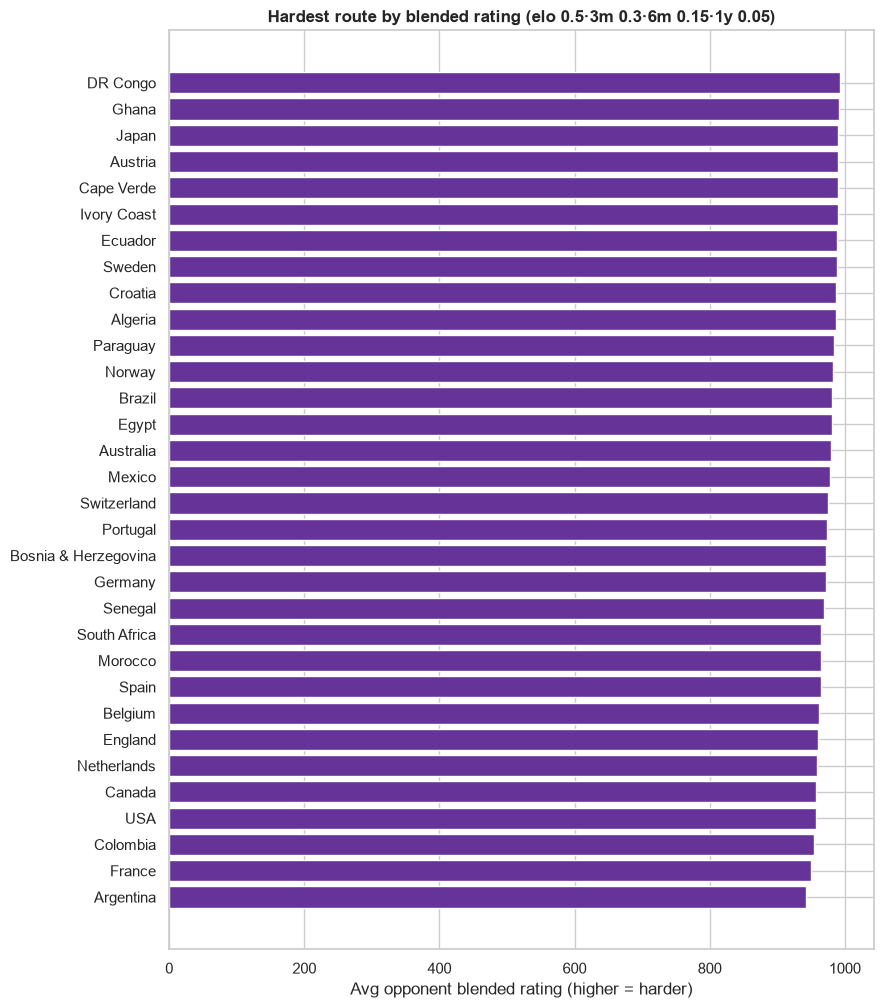

Round-by-round road for DR Congo:
  Final  exp opp blend    1012   win prob 28.0%
  SF     exp opp blend     968   win prob 33.5%
  QF     exp opp blend     979   win prob 32.1%
  R16    exp opp blend    1006   win prob 29.5%
  R32    exp opp blend    1003   win prob 29.7%


In [135]:
_w = "·".join(f"{k} {v}" for k, v in BLEND_WEIGHTS.items())
plot_hardest(blend_routes, "avg_opp_blend",
             f"Hardest route by blended rating ({_w})",
             "Avg opponent blended rating (higher = harder)", "rebeccapurple")
show_road(root, blend_routes.iloc[0]["team"], blend_rating, win_probability, "blend")

### Easiest route — blended rating

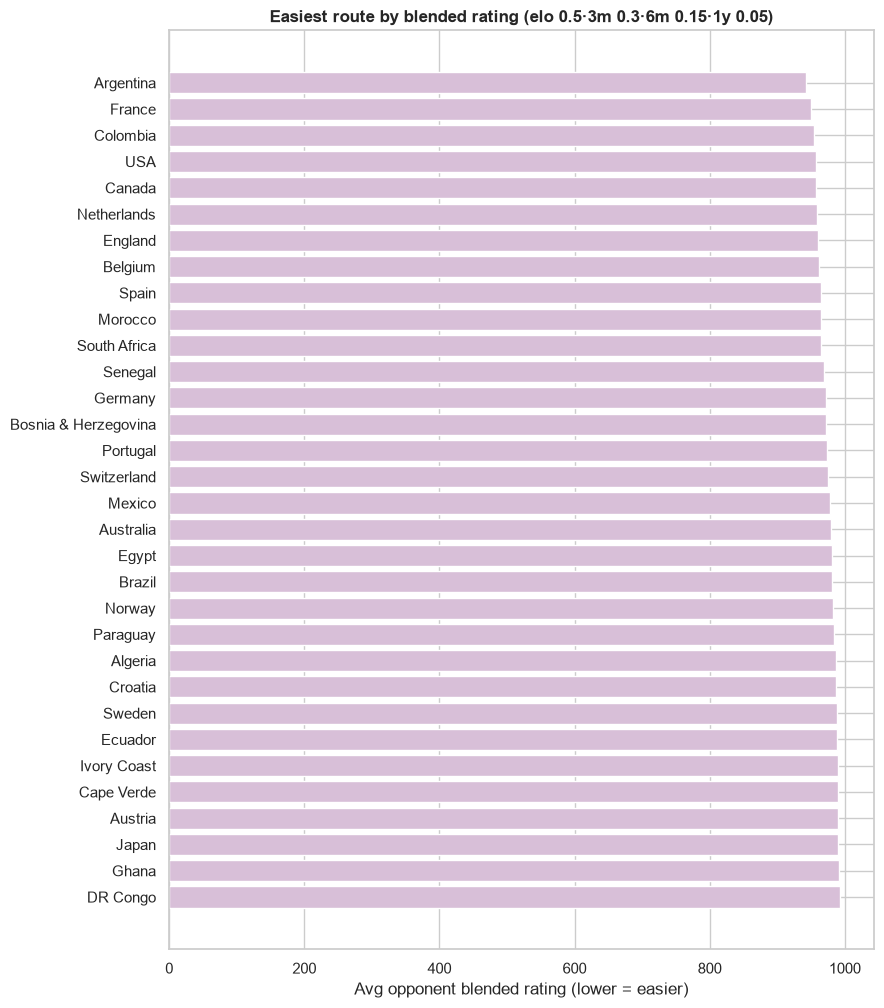

In [136]:
_w = "·".join(f"{k} {v}" for k, v in BLEND_WEIGHTS.items())
plot_easiest(blend_routes, "avg_opp_blend",
             f"Easiest route by blended rating ({_w})",
             "Avg opponent blended rating (lower = easier)", "thistle")

## 11½. Standardized blend (Elo-dominant, scale-honest)

Section 11 weighted Elo and the form deltas **on their raw scales**. Because Elo
spreads ~180 points while the deltas swing only ±40–60, the "0.5 on Elo" actually
delivered **~91% of the variance** — the momentum terms barely moved the ranking
(per-team rank correlation with pure Elo ≈ **0.96**). The weights summed to 1.0 but
did *not* mean what they looked like.

Here we put every input on a common footing first:

1. **z-score** each input across the 32 bracket teams (so a "1" means one standard
   deviation, whatever the raw units);
2. combine with Elo-dominant weights **`0.70·z(Elo) + 0.18·z(Δ3m) + 0.09·z(Δ6m) + 0.03·z(Δ1y)`**
   (Elo 70 %, form 30 % split 6:3:1 across the 3m/6m/1y horizons);
3. **rescale the composite back onto the Elo scale** — same mean and spread as the
   32 teams' Elo.

Step 3 is deliberate. The blended number is fed straight into `win_probability`
(the `/400` model, see `bracket.py` — `advancement_distribution` calls
`prob(ratings[a], ratings[b])`), so keeping it on the Elo scale leaves the
**win-prob model completely unchanged**; raw z-scores (std ≈ 1) would have collapsed
every matchup to ~50/50. Only the *ordering* shifts with form. Net effect: form now
carries ~5× the punch it had in section 11 (rank corr with pure Elo drops to ≈ **0.89**)
while Elo stays clearly in charge.

One caveat worth stating: Elo and momentum are **negatively** correlated here
(r ≈ −0.3 to −0.4 — regression to the mean: strong sides sliding, risers climbing),
so a covariance-based "variance share" misleadingly over-credits Elo. The honest
influence metric is each standardized term's weight, which is exactly what we set.

In [137]:
# Standardized, Elo-dominant blend ("scale-honest" version of section 11).
# Each input is z-scored across the 32 bracket teams so the weights reflect real
# influence, then the composite is rescaled to Elo's mean/spread so the /400
# win-probability model is untouched (raw z-scores -> every match ~50/50).
Z_WEIGHTS = {"elo": 0.70, "3m": 0.18, "6m": 0.09, "1y": 0.03}  # Elo 70% / form 30% (6:3:1)

_inputs = {
    "elo": pd.Series(elo_rating),
    "3m":  pd.Series(change_3m),
    "6m":  pd.Series(change_6m),
    "1y":  pd.Series(change_1y),
}
_idx = pd.Index(teams)                                    # standardize over bracket teams only
_z = {k: (s.reindex(_idx) - s.reindex(_idx).mean()) / s.reindex(_idx).std()
      for k, s in _inputs.items()}

_composite = sum(Z_WEIGHTS[k] * _z[k] for k in Z_WEIGHTS)
_elo32 = _inputs["elo"].reindex(_idx)
# Rescale composite to Elo's mean & std -> identical win-prob "temperature".
zblend_rating = (_elo32.mean() + _composite / _composite.std() * _elo32.std()).to_dict()

zblend_routes = difficulty_table(root, teams, zblend_rating, win_probability, "zblend")
zblend_routes

,team,zblend,avg_opp_zblend,p_champion,hardness_rank
0,Ecuador,1811.709745,2013.957214,0.000943,1
1,DR Congo,1656.918675,2013.244974,0.000030,2
2,Japan,1926.934780,2013.147105,0.007664,3
3,Ghana,1659.765016,2012.264330,0.000034,4
4,Algeria,1808.030983,2011.737184,0.000948,5
5,Norway,1883.217442,2006.715977,0.004121,6
6,Ivory Coast,1894.133131,2004.532840,0.005152,7
7,Cape Verde,1687.140895,1999.360657,0.000065,8
8,Austria,1826.744152,1998.145327,0.001536,9
9,Croatia,1773.531108,1998.048321,0.000573,10


scale : zblend mean=1857.9 std=153.7 | elo mean=1857.9 std=153.7
per-team rank corr vs pure Elo : 0.886  (raw section-11 blend ~0.96)
hardest-route rank corr vs Elo : 0.880


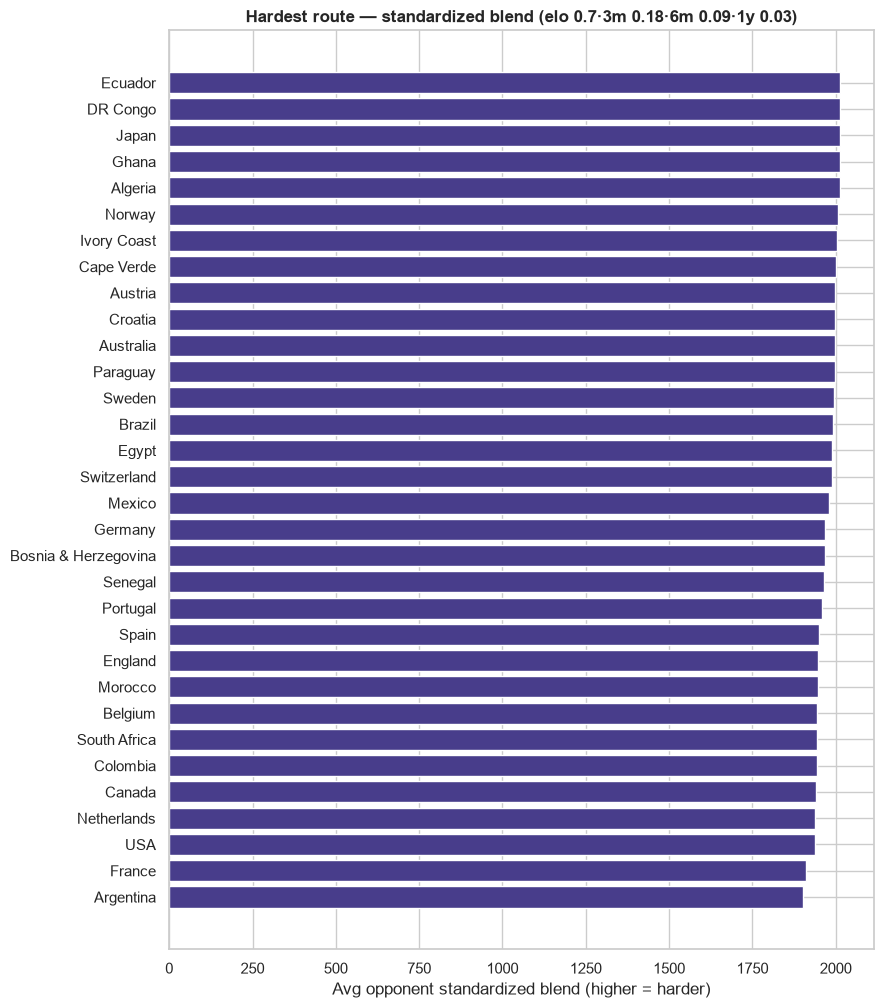

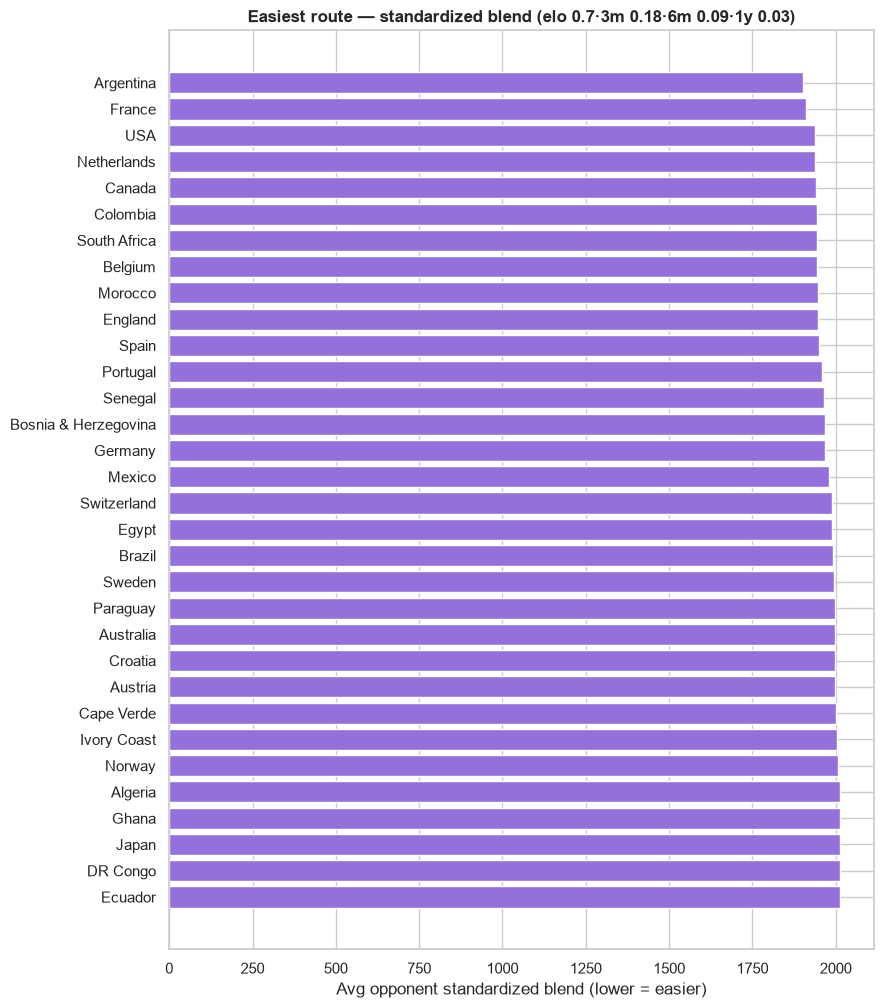

Round-by-round road for Ecuador:
  Final  exp opp zblend    1987   win prob 26.8%
  SF     exp opp zblend    1940   win prob 32.9%
  QF     exp opp zblend    1962   win prob 30.3%
  R16    exp opp zblend    2090   win prob 18.8%
  R32    exp opp zblend    2092   win prob 18.8%


In [138]:
# Sanity check: the standardized blend keeps Elo's scale (so the /400 win-prob
# model is unchanged) but lets form actually move teams.
_zb = pd.Series(zblend_rating).reindex(_idx)
_team_corr = _zb.rank().corr(_elo32.rank())
_hard_corr = (zblend_routes.set_index("team")["avg_opp_zblend"].rank()
              .corr(elo_routes.set_index("team")["avg_opp_elo"].rank()))
print(f"scale : zblend mean={_zb.mean():.1f} std={_zb.std():.1f} | "
      f"elo mean={_elo32.mean():.1f} std={_elo32.std():.1f}")
print(f"per-team rank corr vs pure Elo : {_team_corr:.3f}  (raw section-11 blend ~0.96)")
print(f"hardest-route rank corr vs Elo : {_hard_corr:.3f}")

_w = "·".join(f"{k} {v}" for k, v in Z_WEIGHTS.items())
plot_hardest(zblend_routes, "avg_opp_zblend",
             f"Hardest route — standardized blend ({_w})",
             "Avg opponent standardized blend (higher = harder)", "darkslateblue")
plot_easiest(zblend_routes, "avg_opp_zblend",
             f"Easiest route — standardized blend ({_w})",
             "Avg opponent standardized blend (lower = easier)", "mediumpurple")
show_road(root, zblend_routes.iloc[0]["team"], zblend_rating, win_probability, "zblend")

## 12. Styled — easiest blended route (Excalidraw look)

The same easiest-by-blended-rating chart from section 11, redrawn in **plotly**
with a hand-drawn aesthetic: a Virgil-like sketch font (`Kalam`), warm paper
background, pen-stroke bar outlines, and a thistle→rebeccapurple gradient that
deepens with route difficulty. Team labels are tinted by their group-stage
finish — **gold** for group champions, **silver** for runners-up, **bronze** for
third-place qualifiers (shades deepened to read on the warm paper). Softest road
sits on top.

In [139]:
import plotly.graph_objects as go
from IPython.display import HTML, display

# Pull in an Excalidraw-ish hand-drawn web font (Virgil-like) so the chart
# reads like a sketch rather than a spreadsheet.
display(HTML(
    '<link rel="stylesheet" href="https://fonts.googleapis.com/css2?'
    'family=Kalam:wght@300;400;700&display=swap">'
))
HAND = "Kalam, 'Comic Sans MS', 'Segoe Print', cursive"
INK = "#3d2c5f"          # pen colour
PAPER = "#fdfcf6"        # warm off-white paper

# Group winners / runners-up from the 2026 group stage. Anything not listed is a
# third-place qualifier. The tick labels are tinted by finish: champions gold,
# runners-up silver, third place bronze — shades deepened enough to read on the
# warm paper background.
GROUP_CHAMPIONS = {
    "Mexico", "Switzerland", "Brazil", "USA", "Germany", "Netherlands",
    "Belgium", "Spain", "France", "Argentina", "Colombia", "England",
}
GROUP_RUNNERS_UP = {
    "South Africa", "Canada", "Morocco", "Australia", "Ivory Coast", "Japan",
    "Egypt", "Cape Verde", "Norway", "Austria", "Portugal", "Croatia",
}
GOLD = "#b8860b"         # champions — deep goldenrod
SILVER = "#6b7280"       # runners-up — slate silver
BRONZE = "#9c5a2b"       # third place — bronze


def team_label_color(team):
    if team in GROUP_CHAMPIONS:
        return GOLD
    if team in GROUP_RUNNERS_UP:
        return SILVER
    return BRONZE


def _lerp_hex(c0, c1, t):
    a = tuple(int(c0[i:i + 2], 16) for i in (1, 3, 5))
    b = tuple(int(c1[i:i + 2], 16) for i in (1, 3, 5))
    return tuple(round(a[k] + (b[k] - a[k]) * t) for k in range(3))


def plot_route_excalidraw(df, value_col, title, xlabel, *, easiest,
                          c_lo="#e9d8fb", c_hi="#663399", n=32):
    """Hand-drawn-styled horizontal bar chart of route difficulty (plotly)."""
    # Hardest -> biggest value on top; easiest -> smallest value on top.
    asc = easiest                      # easiest: smallest first
    ordered = df.sort_values(value_col, ascending=asc).head(n).reset_index(drop=True)
    # Plotly stacks the first category at the bottom, so reverse to put the
    # "winner" (top of the ranking) at the top of the chart.
    ordered = ordered[::-1].reset_index(drop=True)

    vals = ordered[value_col]
    span = (vals.max() - vals.min()) or 1.0
    norm = (vals - vals.min()) / span
    fills = [f"rgb{_lerp_hex(c_lo, c_hi, t)}" for t in norm]

    teams_ordered = list(ordered["team"])
    tick_text = [f"<span style='color:{team_label_color(t)}'>{t}</span>"
                 for t in teams_ordered]

    fig = go.Figure(go.Bar(
        x=vals,
        y=teams_ordered,
        orientation="h",
        marker=dict(color=fills, line=dict(color=INK, width=1.4)),
        text=[f"{v:,.0f}" for v in vals],
        textposition="outside",
        textfont=dict(family=HAND, size=13, color=INK),
        cliponaxis=False,
        hovertemplate="<b>%{y}</b><br>" + xlabel.split(" (")[0] +
                      ": %{x:.1f}<extra></extra>",
    ))

    pad = span * 0.08
    fig.update_layout(
        title=dict(text=title, font=dict(family=HAND, size=28, color=INK),
                   x=0.02, xanchor="left", y=0.965),
        font=dict(family=HAND, size=15, color=INK),
        paper_bgcolor=PAPER,
        plot_bgcolor=PAPER,
        bargap=0.34,
        height=860,
        width=920,
        margin=dict(l=150, r=90, t=90, b=64),
        showlegend=False,
        xaxis=dict(
            title=dict(text=xlabel, font=dict(family=HAND, size=15, color=INK)),
            range=[vals.min() - pad, vals.max() + pad * 2.4],
            showgrid=True, gridcolor="rgba(61,44,95,0.10)", gridwidth=1,
            zeroline=False, tickfont=dict(family=HAND, size=12, color=INK),
            showline=True, linecolor=INK, linewidth=1.4,
        ),
        yaxis=dict(
            tickmode="array",
            tickvals=teams_ordered,
            ticktext=tick_text,
            tickfont=dict(family=HAND, size=14),
            showgrid=False, ticksuffix="  ",
            showline=True, linecolor=INK, linewidth=1.4,
        ),
    )
    return fig


_w = "·".join(f"{k} {v}" for k, v in BLEND_WEIGHTS.items())
fig = plot_route_excalidraw(
    blend_routes, "avg_opp_blend",
    "Easiest route by blended rating",
    f"Avg opponent blended rating  ({_w}) — lower = easier",
    easiest=True,
)
fig.show()


## 13. Styled — easiest Elo route (Excalidraw look)

The same hand-drawn treatment as section 12, but ranking the **softest road by
raw Eloratings** (`avg_opp_elo`, lower = easier) instead of the blended rating.
Reuses `plot_route_excalidraw` unchanged — only the data, title, and gradient
swap: a lightsteelblue→steelblue ramp echoes the Elo charts in sections 4 & 9.
Team labels keep the gold/silver/bronze group-finish tint. Easiest road sits on
top.

In [140]:
fig = plot_route_excalidraw(
    elo_routes, "avg_opp_elo",
    "Easiest route by Eloratings",
    "Avg opponent Elo  (/400) — lower = easier",
    easiest=True,
    c_lo="#b0c4de",   # lightsteelblue (softest road)
    c_hi="#4682b4",   # steelblue (toughest of the easy field)
)
fig.show()

## 14. Styled — easiest standardized-blend route (Excalidraw look)

The hand-drawn treatment from sections 12–13 applied to the **standardized,
Elo-dominant blend** from section 11½ (`avg_opp_zblend`, lower = easier). Same
`plot_route_excalidraw` helper, unchanged — only the data, title, and gradient
swap: a light-lavender→darkslateblue ramp echoing the section-11½ charts. Because
the helper **clips the x-axis to the data range**, the ~110-point spread that the
0-based `/400` bar charts flatten now reads clearly. Team labels carry the
gold/silver/bronze group-finish tint. Softest road sits on top.

In [141]:
_w = "·".join(f"{k} {v}" for k, v in Z_WEIGHTS.items())
fig = plot_route_excalidraw(
    zblend_routes, "avg_opp_zblend",
    "Easiest route by standardized blend",
    f"Avg opponent standardized blend  ({_w}) — lower = easier",
    easiest=True,
    c_lo="#cdbdf0",   # light lavender (softest road)
    c_hi="#483d8b",   # darkslateblue (toughest of the easy field)
)
fig.show()